# Cuaderno 05: Análisis Final e Integración de Modelos
**Objetivo:** Integrar los hallazgos de nuestros modelos predictivos (Aprendizaje Supervisado) con un análisis de segmentación de mercado (Aprendizaje No Supervisado). Esta combinación nos permitirá no solo predecir el valor de las propiedades, sino entender la geografía económica que dicta esos precios.



*1. Carga de Datos Estructurados*

Iniciamos cargando nuestro dataset limpio consolidado.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Cargando dataset limpio...")
df = pd.read_csv('../data/RealEstate_California_Clean.csv')
print(f"Dataset cargado con {df.shape[0]} propiedades listas para el análisis final.")

Cargando dataset limpio...
Dataset cargado con 34420 propiedades listas para el análisis final.


*2. Selección del Número Óptimo de Clústeres (Método del Codo)*

Para determinar cuántos segmentos de mercado existen realmente en nuestro dataset, aplicamos la técnica del **Método del Codo (Elbow Method)**. Este análisis mide la **Inercia** (la suma de las distancias al cuadrado de cada punto a su centroide). Buscamos el punto donde la reducción de la inercia deja de ser drástica y comienza a estabilizarse, formando un "codo" visual.

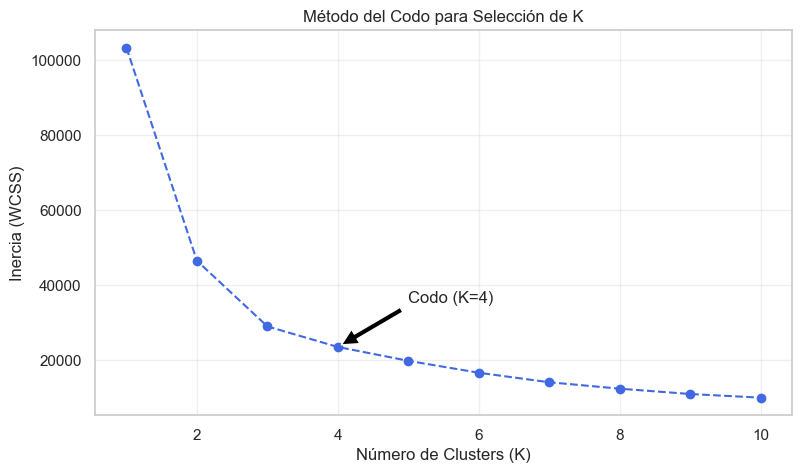

In [5]:
# definimos X_cluster usando el 'df' que cargamos arriba
X_cluster = df[['latitude', 'longitude', 'price']]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Cálculo de la inercia para diferentes valores de K (del 1 al 10)
inercia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

# Visualización del Método del Codo
plt.figure(figsize=(9, 5))
plt.plot(K_range, inercia, marker='o', color='royalblue', linestyle='--')
plt.title('Método del Codo para Selección de K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.annotate('Codo (K=4)', xy=(4, inercia[3]), xytext=(5, inercia[3]*1.5),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.grid(True, alpha=0.3)
plt.show()

*3. Aprendizaje No Supervisado: Segmentación del Mercado (Clustering)*

*Nota analítica: Tras optimizar nuestro Random Forest en el Cuaderno 04, observamos que el modelo pierde precisión al evaluar propiedades de ultra-lujo. Para entender este fenómeno desde una perspectiva de negocio, aplicaremos el algoritmo **K-Means**.*

El objetivo es segmentar el mercado automáticamente basándonos en la relación espacial y económica: **Latitud, Longitud y Precio**.

**Justificación técnica:** Aplicamos un escalado de datos (`StandardScaler`) antes del clustering. Sin esto, la magnitud del precio (millones) habría dominado la distancia matemática, opacando por completo las coordenadas geográficas.

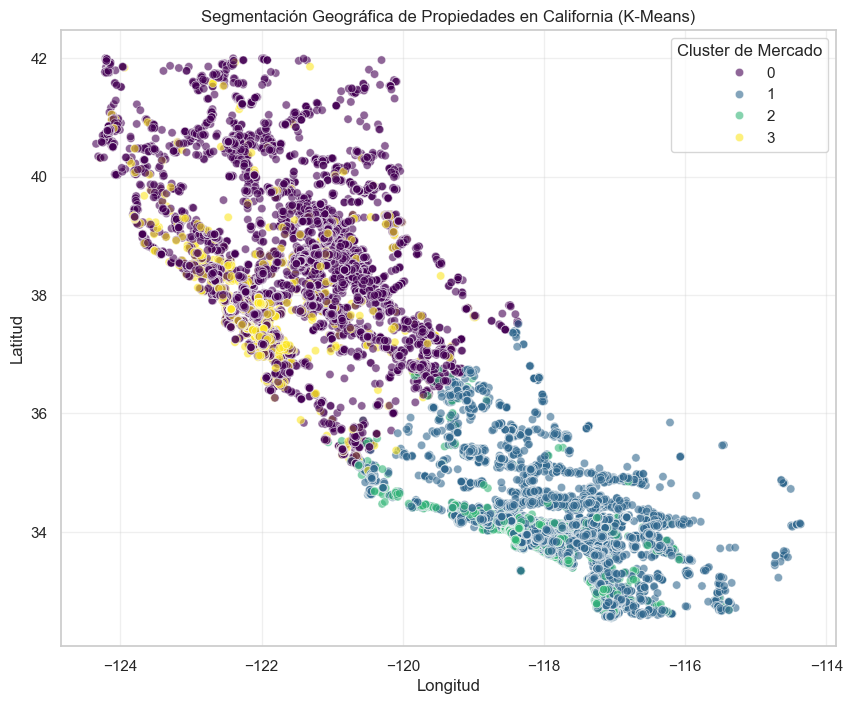

In [2]:
# 1. Aislamos las variables clave para la segmentación
X_cluster = df[['latitude', 'longitude', 'price']]

# 2. Escalado de características (Vital para algoritmos basados en distancias como K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3. Entrenamiento del modelo No Supervisado (K=4 validado previamente por el Método del Codo)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_zona'] = kmeans_final.fit_predict(X_scaled)

# 4. Visualización Espacial de los Clústeres
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='longitude', 
    y='latitude', 
    hue='cluster_zona', 
    palette='viridis', 
    alpha=0.6 
)

plt.title('Segmentación Geográfica de Propiedades en California (K-Means)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Cluster de Mercado')
plt.grid(True, alpha=0.3) 
plt.show()

El gráfico de dispersión anterior revela cómo el algoritmo agrupó las propiedades basándose en su ubicación (Latitud y Longitud) y su valor económico, reconstruyendo visualmente la geografía de California:

1. **Reconstrucción Espacial:** El eje X (Longitud) y el eje Y (Latitud) actúan como un mapa cartesiano. Cada punto representa una propiedad. 
2. **Distribución del Mercado Masivo (Clusters 0 y 1 - Tonos Morados y Verdes):** * Estos grupos presentan una dispersión muy amplia, extendiéndose por todo el territorio interior, el Valle Central y las zonas norte/sur menos costeras. 
   * Geográficamente, ocupan la mayor parte del estado, lo que coincide con los hallazgos estadísticos previos: aquí se concentra el gran volumen de viviendas estándar a precios más accesibles.
3. **Concentración de los Nichos de Lujo (Clusters 2 y 3 - Tonos Turquesa y Amarillos):**
   * A diferencia del mercado masivo, estos puntos están densamente aglomerados en franjas muy específicas del extremo izquierdo y sur del gráfico (la costa oeste de California).
   * Estas agrupaciones coinciden espacialmente con áreas metropolitanas de altísima plusvalía, como el Área de la Bahía de San Francisco (centro-izquierda) y la franja costera de Los Ángeles/San Diego (abajo a la izquierda). 
   * La estrecha aglomeración de estos colores confirma que las propiedades de lujo (las que nuestro modelo Random Forest tendía a subestimar) no están distribuidas al azar, sino fuertemente ancladas a micro-zonas geográficas costeras premium.

**Conclusión:** El algoritmo K-Means validó matemáticamente lo que dicta la teoría inmobiliaria: en California, la distancia hacia la costa es un factor divisor crítico que crea sub-mercados con comportamientos de precio completamente distintos.

*4. Perfilamiento Económico de los Grupos*

Una vez que el algoritmo ha agrupado las casas, extraemos las métricas estadísticas para que el equipo de negocio pueda interpretar qué significa realmente cada grupo.

In [3]:
# Agrupamos los datos por el cluster asignado y calculamos estadísticas descriptivas
resumen_clusters = df.groupby('cluster_zona')['price'].agg(['mean', 'count', 'std']).reset_index()

# Renombramos para la presentación de negocio
resumen_clusters.columns = ['Cluster', 'Precio Promedio (USD)', 'Cantidad de Casas', 'Desviación Estándar']

# Formato financiero para mejor lectura
pd.options.display.float_format = '${:,.2f}'.format

print("--- Tabla de Resumen de Segmentación de Mercado ---")
display(resumen_clusters)

# Guardamos el insight final en disco
resumen_clusters.to_csv('../data/resumen_estadistico_clusters.csv', index=False)

--- Tabla de Resumen de Segmentación de Mercado ---


,Cluster,Precio Promedio (USD),Cantidad de Casas,Desviación Estándar
0,0,"$592,138.84",12744,"$362,143.83"
1,1,"$652,506.75",16523,"$387,064.19"
2,2,"$2,647,320.14",2513,"$867,905.96"
3,3,"$2,346,309.52",2640,"$855,379.02"


Ahora entendemos que el mercado inmobiliario de California está fuertemente dividido por zonas de valor geográfico.

* Los Clusters 0 y 1 representan el mercado masivo, con casi 30.000 propiedades de precios accesibles distribuidas por todo el estado.

* Los Clusters 2 y 3 logran aislar los nichos de lujo. Aunque son pocos puntos en el mapa, su valor promedio supera los 2.3 millones de dólares, concentrándose principalmente en la franja costera.

* Los colores que está muy amontonado el modelo agrupó estas casas porque comparten una densidad urbana y rangos de precios similares

* La desviación estándar en los clusters de lujo (2 y 3) es más alta, indica que en el segmento premium hay mucha más variedad de precios (desde mansiones caras hasta propiedades extremas) comparado con el mercado estándar.

## Análisis Integrado y Conclusiones del Proyecto

Al cruzar los resultados de nuestro modelo predictivo (Random Forest Optimizado) con nuestro modelo de segmentación (K-Means), llegamos a las siguientes conclusiones fundamentales para la estrategia del negocio:

1. **La Dualidad del Mercado Californiano:**
   * La tabla de K-Means demuestra que el mercado está fuertemente dividido. Los **Clusters 0 y 1** representan el mercado masivo y accesible (miles de propiedades distribuidas por todo el estado). 
   * Por otro lado, los **Clusters 2 y 3** logran aislar matemáticamente los nichos de lujo. Son pocas propiedades, pero su valor promedio es dramáticamente superior y se concentran en franjas costeras específicas.

2. **Explicación del Error Predictivo:**
   * En el Cuaderno 03 observamos que el Random Forest subestimaba el precio de las casas más caras. La alta *Desviación Estándar* descubierta en los Clusters de lujo (2 y 3) explica este fenómeno: en el segmento premium, los precios son altamente volátiles y dependen de características intangibles (vistas exclusivas, arquitectura de autor) que escapan a los metros cuadrados o cantidad de baños.

3. **Recomendación Final de Implementación:**
   * **Para el 90% del mercado (Clusters Masivos):** Recomendamos desplegar de inmediato nuestro pipeline de **Random Forest**, ya que demostró un MAE altamente competitivo y estable.
   * **Para el nicho de ultra-lujo (Clusters Premium):** Recomendamos utilizar el algoritmo como una línea base de tasación, pero exigir una revisión manual por parte de un tasador experto humano, dada la extrema variabilidad matemática de este sector.